In [1]:
from elosports.elo import Elo
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/clean/baseball_games.csv')
df

,date,away,home,away_score,home_score,winning_team
0,2007-02-16,taylor (in),tennessee temple,5,4,taylor (in)
1,2007-02-16,taylor (in),tennessee temple,4,0,taylor (in)
2,2007-02-17,taylor (in),tennessee temple,9,3,taylor (in)
3,2007-02-17,taylor (in),tennessee temple,5,6,tennessee temple
4,2007-02-22,huntington (in),freed-hardeman,12,6,huntington (in)
...,...,...,...,...,...,...
5005,2026-05-23,doane (ne),taylor (in),8,10,taylor (in)
5006,2026-05-25,taylor (in),lewis-clark state,8,5,taylor (in)
5007,2026-05-26,taylor (in),mid-america christian,13,4,taylor (in)
5008,2026-05-28,william carey (ms),taylor (in),4,7,taylor (in)


# Elo Rating System

In [3]:
allTeams = set(df.away.tolist())
allTeams.update(df.home.tolist())
eloLeague = Elo(k=20)

In [4]:
for team in allTeams:
    eloLeague.addPlayer(team)

for game in df.iterrows():
    
    df.loc[game[0], 'away_elo_pre'] = eloLeague.ratingDict[game[1].away]
    df.loc[game[0], 'home_elo_pre'] = eloLeague.ratingDict[game[1].home]
    df.loc[game[0], 'elo_prob_away'] = eloLeague.expectResult(eloLeague.ratingDict[game[1].away], eloLeague.ratingDict[game[1].home])
    df.loc[game[0], 'elo_prob_home'] = eloLeague.expectResult(eloLeague.ratingDict[game[1].home], eloLeague.ratingDict[game[1].away])

    if game[1].away_score > game[1].home_score:
        eloLeague.gameOver(game[1].away, game[1].home, True)
    else:
        eloLeague.gameOver(game[1].home, game[1].away, 0)
        
    df.loc[game[0], 'away_elo_post'] = eloLeague.ratingDict[game[1].away]
    df.loc[game[0], 'home_elo_post'] = eloLeague.ratingDict[game[1].home]

for team in eloLeague.ratingDict.keys():
    print(team, eloLeague.ratingDict[team])

point park 1449.5524098097997
viterbo 1452.4141317184137
western michigan 1506.3379324699467
alice lloyd 1471.1167200929535
florida memorial 1510.0068836346475
lydon state college 1489.5606304973085
calumet 1423.8438002799558
madonna 1504.1740022399724
peru state 1511.910065283516
evangel 1496.5787308433414
lourdes 1403.5191238179998
the master's university 1514.3833069113748
indiana 1524.2746978171797
brewton-parker (ga) 1490.6206367015202
freed-hardeman 1512.6623755546066
ohio mid-western college 1477.2999491908545
geneva college 1495.6076812019842
miami-hamilton university 1527.1772202486873
purdue university calumet 1512.19618690034
mount vernon nazarene (oh) 1479.3934536349952
indiana south bend 1313.2022700762814
reinhardt 1665.9706076919497
warner (fl) 1475.834222522889
davenport university 1505.8099052994362
northwestern 1479.715169436495
brescia 1534.2508007822787
baker 1513.3494514097936
bellarmine 1548.5660082837442
bluefield 1540.8612127531449
dickinson state 1507.860161863

In [5]:
df

,date,away,home,away_score,home_score,winning_team,away_elo_pre,home_elo_pre,elo_prob_away,elo_prob_home,away_elo_post,home_elo_post
0,2007-02-16,taylor (in),tennessee temple,5,4,taylor (in),1500.000000,1500.000000,0.500000,0.500000,1507.198700,1492.801300
1,2007-02-16,taylor (in),tennessee temple,4,0,taylor (in),1507.198700,1492.801300,0.520708,0.479292,1514.020123,1485.979877
2,2007-02-17,taylor (in),tennessee temple,9,3,taylor (in),1514.020123,1485.979877,0.540266,0.459734,1520.493076,1479.506924
3,2007-02-17,taylor (in),tennessee temple,5,6,tennessee temple,1520.493076,1479.506924,0.558712,0.441288,1506.644147,1493.355853
4,2007-02-22,huntington (in),freed-hardeman,12,6,huntington (in),1500.000000,1500.000000,0.500000,0.500000,1507.198700,1492.801300
...,...,...,...,...,...,...,...,...,...,...,...,...
5005,2026-05-23,doane (ne),taylor (in),8,10,taylor (in),1500.000000,1837.435036,0.125381,0.874619,1495.937208,1841.497828
5006,2026-05-25,taylor (in),lewis-clark state,8,5,taylor (in),1841.497828,1524.229562,0.861325,0.138675,1843.158251,1522.569139
5007,2026-05-26,taylor (in),mid-america christian,13,4,taylor (in),1843.158251,1500.000000,0.878188,0.121812,1844.605405,1498.552845
5008,2026-05-28,william carey (ms),taylor (in),4,7,taylor (in),1526.540510,1844.605405,0.138128,0.861872,1522.104769,1849.041147


In [6]:
eloLeague.expectResult(eloLeague.ratingDict['grace (in)'], eloLeague.ratingDict['goshen (in)'])

0.7249352776384724

In [7]:
eloLeague.ratingDict['grace (in)']

1335.675742376528

In [8]:
df.to_csv('../data/clean/baseball_games_elo.csv', index=False)

# Visualization

Text(0, 0.5, 'Teams')

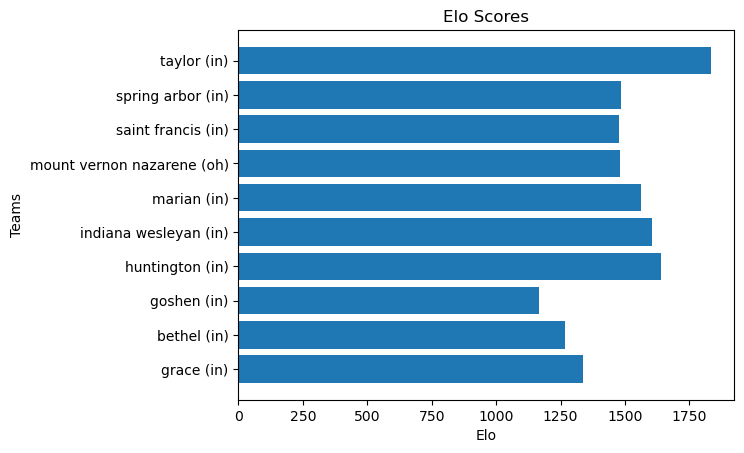

In [9]:
teams = ['grace (in)', 'bethel (in)', 'goshen (in)', 'huntington (in)', 'indiana wesleyan (in)', 'marian (in)', 'mount vernon nazarene (oh)', 'saint francis (in)', 'spring arbor (in)', 'taylor (in)']

elo_count = []
for team in teams:
    elo_count.append(eloLeague.ratingDict[team])

plt.barh(teams, elo_count)
plt.title('Elo Scores')
plt.xlabel('Elo')
plt.ylabel('Teams')

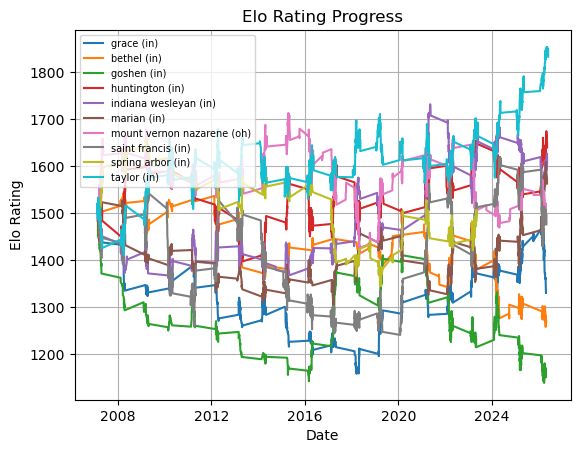

In [10]:
df['date'] = pd.to_datetime(df['date'])

#teams = ['grace (in)', 'goshen (in)']
for team in teams:
    team1_games = df[df['away'] == team][['date', 'away_elo_post']].rename(columns={'away_elo_post': 'elo'})
    
    team2_games = df[df['home'] == team][['date', 'home_elo_post']].rename(columns={'home_elo_post': 'elo'})

    team_games = pd.concat([team1_games, team2_games]).sort_values('date')

    plt.plot(team_games['date'], team_games['elo'], label=team)

plt.title('Elo Rating Progress')
plt.xlabel('Date')
plt.ylabel('Elo Rating')
plt.legend(fontsize=7, loc='upper left')
plt.grid(True)
plt.show()